# Comment Classification
Predict the toxicity label (0–3) of online comments using text, engagement, and demographic features.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
import copy
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.decomposition import TruncatedSVD
from scipy.optimize import minimize

import scipy.sparse as sp
import lightgbm as lgb
import xgboost as xgb

## 1. Load Data

In [2]:
train_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_df  = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

print('train shape:', train_df.shape)
print('test shape:', test_df.shape)
train_df.head()

train shape: (198000, 15)
test shape: (102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


## 2. Exploratory Data Analysis

In [3]:
# feature types at a glance:
# numerical  - upvote, downvote, if_1, if_2, emoticon_1/2/3
# categorical - race, religion, gender, disability
# text        - comment (free-form)
# datetime    - created_date
# target      - label (0=non-toxic, 1=toxic, 2=very toxic, 3=extremely toxic)

print('column dtypes:')
print(train_df.dtypes)
print()
print('numerical columns:', list(train_df.select_dtypes(include='number').columns))
print('categorical columns: race, religion, gender, disability')
print('text column: comment')

column dtypes:
created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object

numerical columns: ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'label']
categorical columns: race, religion, gender, disability
text column: comment


In [4]:
# demographic columns (race, religion, gender) have a lot of nulls
# but missing here means the user didn't share that info, which is itself a signal
# so we don't impute them - the pipeline treats NaN as its own 'missing' category

print('missing values in train:')
missing = train_df.isna().sum()
print(missing[missing > 0])
print()
print('missing values in test:')
missing_test = test_df.isna().sum()
print(missing_test[missing_test > 0])
print()
print('Note: demographic NaNs are treated as a separate category, not imputed.')

missing values in train:
race        145423
religion    145423
gender      145423
comment          1
dtype: int64

missing values in test:
race        75269
religion    75269
gender      75269
dtype: int64

Note: demographic NaNs are treated as a separate category, not imputed.


label distribution:
label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

class proportions:
label
0    0.577
2    0.315
1    0.080
3    0.028
Name: proportion, dtype: float64


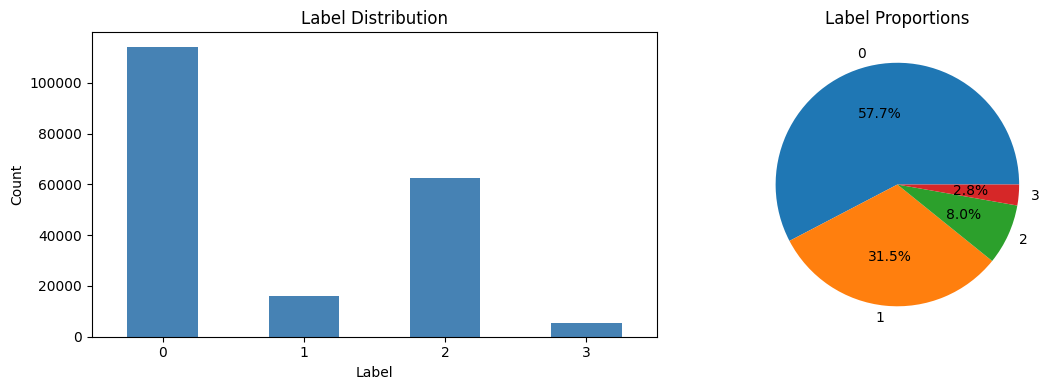

In [5]:
# --- Label distribution ---
print('label distribution:')
print(train_df['label'].value_counts())
print()
print('class proportions:')
print(train_df['label'].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Label Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

train_df['label'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', labels=['0','1','2','3'])
axes[1].set_title('Label Proportions')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# The dataset is heavily imbalanced - class 0 dominates.
# This is why we use class weights and macro F1 as the metric.

In [6]:
# --- Demographic value counts ---
for col in ['race', 'religion', 'gender', 'disability']:
    print(f'\n{col}:')
    print(train_df[col].value_counts(dropna=False))


race:
race
NaN       145423
none       39682
white       5486
black       3869
other       1654
asian       1263
latino       623
Name: count, dtype: int64

religion:
religion
NaN          145423
none          38249
christian      7191
muslim         4930
jewish         1244
other           547
atheist         219
buddhist        100
hindu            97
Name: count, dtype: int64

gender:
gender
NaN            145423
none            36161
female           8037
male             7549
transgender       622
other             208
Name: count, dtype: int64

disability:
disability
False    195257
True       2743
Name: count, dtype: int64


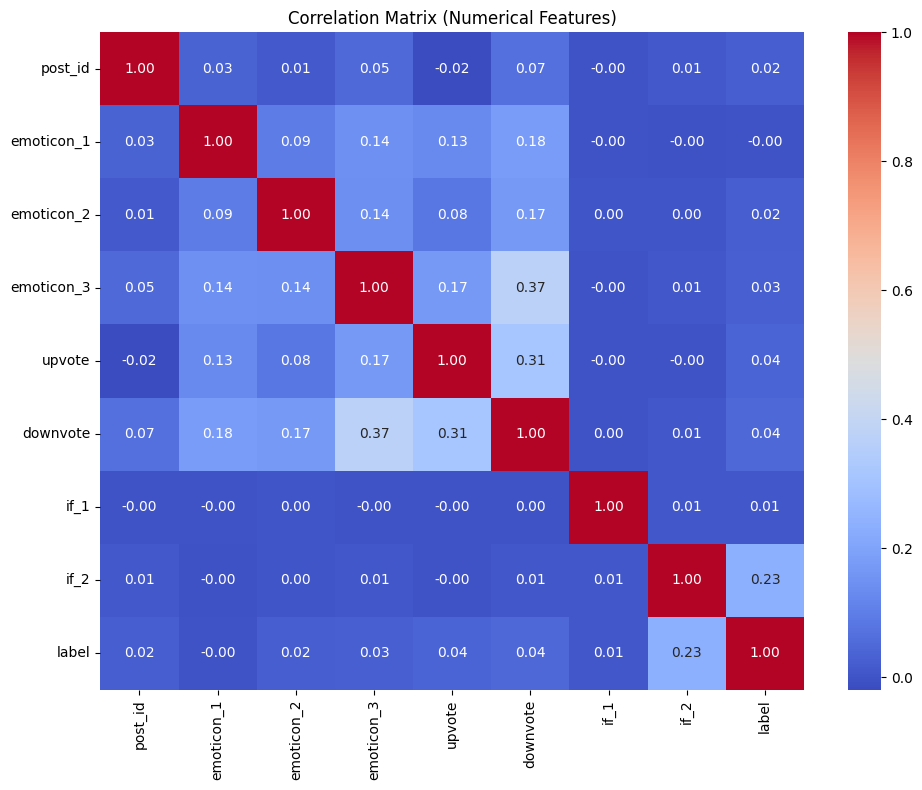

In [7]:
# --- Correlation heatmap (numerical features) ---
num_cols = train_df.select_dtypes(include=np.number).columns
corr = train_df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Correlation Matrix (Numerical Features)')
plt.tight_layout()
plt.show()

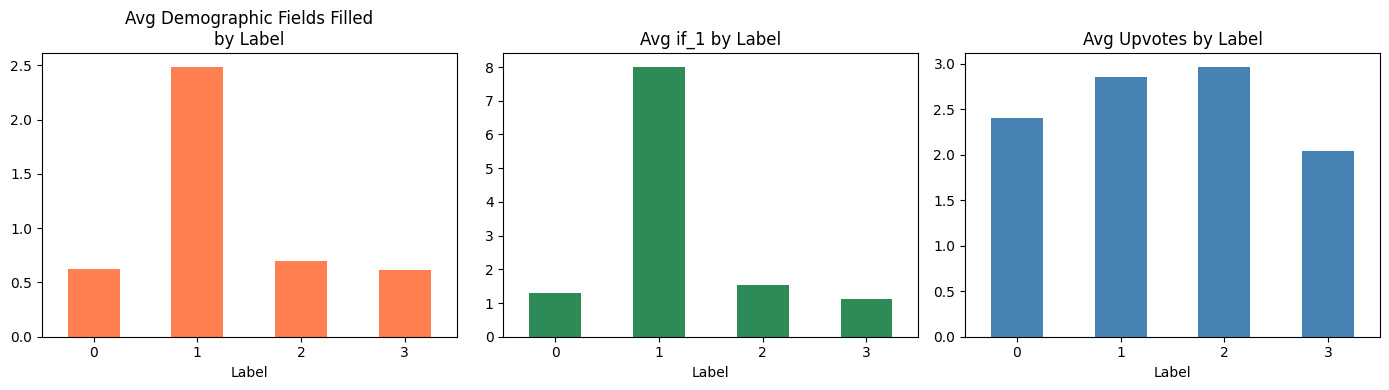

avg demo_count by label:
label
0    0.622
1    2.489
2    0.701
3    0.613
Name: demo_count, dtype: float64

race vs label (row proportions):


label,0,1,2,3
race,,,,
NaN,0.622,0.019,0.329,0.030
asian,0.451,0.288,0.241,0.019
black,0.157,0.692,0.143,0.007
latino,0.440,0.321,0.230,0.010
none,0.519,0.155,0.302,0.024
other,0.409,0.296,0.274,0.022
white,0.168,0.608,0.212,0.011



disability vs label:


label,0,1,2,3
disability,,,,
False,0.580,0.079,0.313,0.028
True,0.314,0.155,0.509,0.022


In [8]:
# --- Key relationships between features and label ---
train_df['demo_count'] = train_df[['race','religion','gender']].notna().sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# demo_count by label
train_df.groupby('label')['demo_count'].mean().plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Avg Demographic Fields Filled\nby Label')
axes[0].set_xlabel('Label')
axes[0].tick_params(rotation=0)

# if_1 by label
train_df.groupby('label')['if_1'].mean().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Avg if_1 by Label')
axes[1].set_xlabel('Label')
axes[1].tick_params(rotation=0)

# upvote by label
train_df.groupby('label')['upvote'].mean().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Avg Upvotes by Label')
axes[2].set_xlabel('Label')
axes[2].tick_params(rotation=0)

plt.tight_layout()
plt.show()

print('avg demo_count by label:')
print(train_df.groupby('label')['demo_count'].mean().round(3))

print('\nrace vs label (row proportions):')
display(pd.crosstab(train_df['race'].fillna('NaN'), train_df['label'], normalize='index').round(3))

print('\ndisability vs label:')
display(pd.crosstab(train_df['disability'], train_df['label'], normalize='index').round(3))

## 3. Feature Engineering

In [9]:
# build derived features from the raw columns
# covers text stats, datetime parts, engagement ratios, and demographic flags


def build_features(df):
    out = df.copy()

    # text cleaning
    out['comment'] = out['comment'].fillna('').astype(str)
    out['comment_clean'] = out['comment'].str.replace(r'\s+', ' ', regex=True).str.strip()
    out['char_count'] = out['comment_clean'].str.len()
    words = out['comment_clean'].str.split()
    out['word_count'] = words.str.len().fillna(0).astype(int)

    # punctuation / style
    out['excl_count'] = out['comment_clean'].str.count('!')
    out['quest_count'] = out['comment_clean'].str.count(r'\?')
    out['caps_ratio'] = out['comment'].apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
    out['url_count'] = out['comment'].str.count(r'https?://|www\.')
    out['has_url'] = (out['url_count'] > 0).astype(int)
    out['quote_count'] = out['comment'].str.count('"')
    out['ellipsis_count'] = out['comment'].str.count(r'\.\.\.')
    out['repeated_punct_count'] = out['comment'].str.count(r'([!?.,])\1+')

    # word-level
    unique_counts = words.apply(lambda x: len(set(x)) if isinstance(x, list) and len(x) > 0 else 0)
    out['unique_word_ratio'] = unique_counts / out['word_count'].clip(lower=1)
    out['avg_word_len'] = words.apply(lambda x: np.mean([len(w) for w in x]) if isinstance(x, list) and len(x) > 0 else 0)
    out['std_word_len'] = words.apply(lambda x: np.std([len(w) for w in x]) if isinstance(x, list) and len(x) > 1 else 0)
    out['all_caps_word_count'] = words.apply(lambda x: sum(w.isupper() and len(w) > 1 for w in x) if isinstance(x, list) else 0)
    out['max_word_len'] = words.apply(lambda x: max((len(w) for w in x), default=0) if isinstance(x, list) else 0)
    out['digit_token_count'] = words.apply(lambda x: sum(any(ch.isdigit() for ch in w) for w in x) if isinstance(x, list) else 0)
    out['symbol_token_count'] = words.apply(lambda x: sum(any(not ch.isalnum() for ch in w) for w in x) if isinstance(x, list) else 0)
    out['long_word_count'] = words.apply(lambda x: sum(len(w) >= 12 for w in x) if isinstance(x, list) else 0)
    out['short_word_ratio'] = words.apply(lambda x: (sum(len(w) <= 3 for w in x) / max(len(x), 1)) if isinstance(x, list) else 0)
    out['repeated_char_token_count'] = words.apply(lambda x: sum(bool(re.search(r'(.)\\1{2,}', w.lower())) for w in x) if isinstance(x, list) else 0)
    out['mixed_char_token_count'] = words.apply(lambda x: sum(bool(re.search(r'(?=.*[A-Za-z])(?=.*[^A-Za-z])', w)) for w in x) if isinstance(x, list) else 0)

    sentence_parts = out['comment_clean'].str.split(r'[.!?]+')
    out['sentence_count'] = sentence_parts.apply(lambda x: sum(bool(part.strip()) for part in x) if isinstance(x, list) else 0)
    out['avg_sentence_len'] = sentence_parts.apply(lambda x: np.mean([len(part.split()) for part in x if part.strip()]) if isinstance(x, list) and any(part.strip() for part in x) else 0)

    # datetime features
    out['created_date'] = pd.to_datetime(out['created_date'], errors='coerce', utc=True)
    out['comment_hour'] = out['created_date'].dt.hour.astype(int)
    out['comment_dayofweek'] = out['created_date'].dt.dayofweek.astype(int)
    out['comment_month'] = out['created_date'].dt.month.astype(int)
    out['comment_year'] = out['created_date'].dt.year.astype(int)

    # engagement
    out['vote_ratio'] = out['upvote'] / (out['downvote'] + 1)
    out['vote_total'] = out['upvote'] + out['downvote']
    out['emoticon_total'] = out['emoticon_1'] + out['emoticon_2'] + out['emoticon_3']
    out['has_emoticon'] = (out['emoticon_total'] > 0).astype(int)

    # log transforms (reduce skew)
    out['if_1_log'] = np.log1p(out['if_1'])
    out['if_2_log'] = np.log1p(out['if_2'])
    out['upvote_log'] = np.log1p(out['upvote'])
    out['downvote_log'] = np.log1p(out['downvote'])

    # interaction
    out['if1_if2_ratio'] = out['if_1'] / (out['if_2'] + 1)
    out['if1_gt0'] = (out['if_1'] > 0).astype(int)

    # demographic meta-features
    out['demo_count'] = out[['race', 'religion', 'gender']].notna().sum(axis=1)
    out['has_any_demo'] = (out['demo_count'] > 0).astype(int)
    out['race_missing'] = out['race'].isna().astype(int)
    out['religion_missing'] = out['religion'].isna().astype(int)
    out['gender_missing'] = out['gender'].isna().astype(int)
    out['all_demo_missing'] = (out['demo_count'] == 0).astype(int)
    out['disability_enc'] = out['disability'].astype(int)
    out['disability_str'] = out['disability'].fillna(False).astype(str)

    race_fill = out['race'].fillna('missing').astype(str)
    religion_fill = out['religion'].fillna('missing').astype(str)
    gender_fill = out['gender'].fillna('missing').astype(str)
    out['race_gender'] = race_fill + '__' + gender_fill
    out['race_religion'] = race_fill + '__' + religion_fill
    out['gender_religion'] = gender_fill + '__' + religion_fill
    out['demo_signature'] = race_fill + '__' + religion_fill + '__' + gender_fill + '__' + out['disability_str']
    out['demo_missing_pattern'] = out['race_missing'].astype(str) + out['religion_missing'].astype(str) + out['gender_missing'].astype(str)

    return out

train_feat = build_features(train_df)
test_feat = build_features(test_df)

print('features built:', train_feat.shape[1], 'columns')

features built: 66 columns


In [10]:
# aggregate stats at the post level (per post_id)
# since all test post_ids exist in train, we can safely use train labels here


# post-level aggregate features
# all test post_ids appear in training so we can safely use train labels here
post_agg = train_feat.groupby('post_id').agg(
    post_count=('upvote', 'count'),
    post_avg_upvote=('upvote', 'mean'),
    post_avg_downvote=('downvote', 'mean'),
    post_avg_if1=('if_1', 'mean'),
    post_avg_if2=('if_2', 'mean'),
    post_avg_char_count=('char_count', 'mean'),
)

for c in [0, 1, 2, 3]:
    post_agg[f'post_label_{c}_rate'] = train_feat.groupby('post_id')['label'].apply(lambda x: (x == c).mean())

def add_post_stats(df, post_table):
    out = df.sort_values(['post_id', 'created_date']).copy()
    grp = out.groupby('post_id', sort=False)
    out['post_comment_rank'] = grp.cumcount()
    local_count = grp['post_id'].transform('size')
    out['post_comment_position'] = out['post_comment_rank'] / np.maximum(local_count - 1, 1)
    out['seconds_since_prev_comment'] = grp['created_date'].diff().dt.total_seconds().fillna(0)
    out['seconds_since_first_comment'] = (out['created_date'] - grp['created_date'].transform('min')).dt.total_seconds().fillna(0)
    out = out.join(post_table, on='post_id')
    out['upvote_vs_post_avg'] = out['upvote'] - out['post_avg_upvote']
    out['downvote_vs_post_avg'] = out['downvote'] - out['post_avg_downvote']
    out['if1_vs_post_avg'] = out['if_1'] - out['post_avg_if1']
    out['if2_vs_post_avg'] = out['if_2'] - out['post_avg_if2']
    out['char_count_vs_post_avg'] = out['char_count'] - out['post_avg_char_count']
    return out.sort_index()

train_feat = add_post_stats(train_feat, post_agg)
test_feat = add_post_stats(test_feat, post_agg)

print('post features added, new shape:', train_feat.shape)

post features added, new shape: (198000, 85)


In [11]:
# smooth mean-target encoding for demographic columns
# done out-of-fold (5 folds) to avoid leaking the target into the features
# smoothing=20 pulls rare categories toward the global rate


# target encoding for demographic columns (out-of-fold to avoid leakage)
te_cols = ['race', 'religion', 'gender', 'disability_str', 'race_gender', 'race_religion', 'gender_religion', 'demo_signature', 'demo_missing_pattern']
classes = [0, 1, 2, 3]
smoothing = 20.0

n = len(train_feat)
global_rate = {c: (train_feat['label'] == c).sum() / n for c in classes}

te_train = {}
for col in te_cols:
    for c in classes:
        te_train[f'{col}_p{c}'] = np.full(n, global_rate[c], dtype=np.float32)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for tr_idx, val_idx in kf.split(train_feat, train_feat['label']):
    tr_fold = train_feat.iloc[tr_idx]
    val_fold = train_feat.iloc[val_idx]
    for col in te_cols:
        for c in classes:
            cname = f'{col}_p{c}'
            stats = tr_fold.assign(_t=(tr_fold['label'] == c).astype(int)).groupby(col, observed=True)['_t'].agg(['sum', 'count'])
            rates = (stats['sum'] + smoothing * global_rate[c]) / (stats['count'] + smoothing)
            te_train[cname][val_idx] = val_fold[col].map(rates).fillna(global_rate[c]).values

for cname, arr in te_train.items():
    train_feat[cname] = arr

for col in te_cols:
    for c in classes:
        cname = f'{col}_p{c}'
        stats = train_feat.assign(_t=(train_feat['label'] == c).astype(int)).groupby(col, observed=True)['_t'].agg(['sum', 'count'])
        rates = (stats['sum'] + smoothing * global_rate[c]) / (stats['count'] + smoothing)
        test_feat[cname] = test_feat[col].map(rates).fillna(global_rate[c]).values

print('target encoding done, shape:', train_feat.shape)

target encoding done, shape: (198000, 121)


## 4. Preprocessing Pipeline

Uses sklearn `Pipeline` and `ColumnTransformer` to keep all preprocessing steps clean and leak-free:

| Step | Transformer | Applied to |
|------|-------------|------------|
| Text (word n-grams) | `TfidfVectorizer` | `comment_clean` |
| Text (SVD) | `TfidfVectorizer → TruncatedSVD` | `comment_clean` |
| Text (char n-grams) | `TfidfVectorizer` | `comment_clean` |
| Categorical | `SimpleImputer → OneHotEncoder` | race, religion, gender |
| Numerical | `StandardScaler` | all numeric features |

Each CV fold gets a fresh `deepcopy` of the preprocessor, fitted only on the training split, so there's no leakage into validation.

Demographic NaN values are intentionally kept as their own category (`'missing'`) rather than imputed.

In [12]:
categorical_cols = ['race', 'religion', 'gender']

numerical_cols = [
    # raw engagement
    'emoticon_1', 'emoticon_2', 'emoticon_3',
    'upvote', 'downvote', 'if_1', 'if_2',
    # text-derived
    'char_count', 'word_count',
    # datetime
    'comment_hour', 'comment_dayofweek', 'comment_month', 'comment_year',
    # punctuation/style
    'url_count', 'has_url', 'quote_count', 'ellipsis_count', 'repeated_punct_count',
    'all_caps_word_count', 'max_word_len', 'digit_token_count', 'symbol_token_count',
    'long_word_count', 'short_word_ratio', 'sentence_count', 'avg_sentence_len',
    'std_word_len', 'repeated_char_token_count', 'mixed_char_token_count',
    # engagement derived
    'vote_ratio', 'vote_total', 'emoticon_total', 'has_emoticon',
    'excl_count', 'quest_count', 'caps_ratio', 'unique_word_ratio',
    'avg_word_len', 'demo_count', 'has_any_demo',
    # demographic missingness flags
    'race_missing', 'religion_missing', 'gender_missing', 'all_demo_missing',
    # log-transformed to reduce skew
    'if_1_log', 'if_2_log', 'upvote_log', 'downvote_log',
    'if1_if2_ratio', 'if1_gt0',
    'disability_enc',
    # post-level aggregates
    'post_count', 'post_avg_upvote', 'post_avg_downvote',
    'post_avg_if1', 'post_avg_if2', 'post_avg_char_count',
    'post_label_0_rate', 'post_label_1_rate', 'post_label_2_rate', 'post_label_3_rate',
    'post_comment_rank', 'post_comment_position',
    'seconds_since_prev_comment', 'seconds_since_first_comment',
    'upvote_vs_post_avg', 'downvote_vs_post_avg', 'if1_vs_post_avg',
    'if2_vs_post_avg', 'char_count_vs_post_avg',
]
numerical_cols += [f'{col}_p{c}' for col in te_cols for c in classes]

# categorical: fill NaN as its own 'missing' category, then one-hot encode
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
])

# numerical: standard scale (with_mean=False keeps sparse compatibility)
num_pipeline = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
])

# combine everything into one ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        # word n-gram TF-IDF
        ('word',     TfidfVectorizer(analyzer='word', ngram_range=(1, 2),
                                     min_df=10, max_df=0.95, max_features=8000,
                                     sublinear_tf=True),              'comment_clean'),
        # word TF-IDF reduced to 50 dims via SVD
        ('word_svd', Pipeline([
            ('tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1, 2),
                                      min_df=10, max_df=0.95, max_features=8000,
                                      sublinear_tf=True)),
            ('svd',   TruncatedSVD(n_components=50, random_state=42)),
        ]),                                                            'comment_clean'),
        # char n-gram TF-IDF (good for catching typos and informal spelling)
        ('char',     TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5),
                                     min_df=20, max_df=0.95, max_features=5000,
                                     sublinear_tf=True),              'comment_clean'),
        ('categorical', cat_pipeline, categorical_cols),
        ('numerical',   num_pipeline, numerical_cols),
    ],
    remainder='drop',
    n_jobs=-1,
)

print('preprocessor ready')
print('numerical features:', len(numerical_cols))
print('categorical features:', categorical_cols)

preprocessor ready
numerical features: 106
categorical features: ['race', 'religion', 'gender']


## 5. Model Training & Hyperparameter Tuning

Training 3 models using 2-fold stratified CV:

| # | Model | Notes |
|---|-------|-------|
| 1 | **LightGBM** | Main model; hyperparams tuned via grid search (see Cell 19) |
| 2 | **Logistic Regression** | Linear baseline |
| 3 | **Random Forest** | Tree baseline; trained on 30% subsample to keep runtime reasonable |

Each fold deep-copies the preprocessor and fits it only on train split data to prevent leakage.

LightGBM hyperparameters (`num_leaves=127`, `learning_rate=0.03`) were selected from a small grid search.

In [13]:
X = train_feat.drop(columns=['label'])
y = train_feat['label']

# higher weight on minority classes to handle the imbalance
class_weight = {0: 1.0, 1: 4.0, 2: 2.0, 3: 8.0}

skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

# out-of-fold prediction arrays - one row per training sample, one column per class
oof_lgb = np.zeros((len(X), 4))
test_lgb = np.zeros((len(test_feat), 4))

oof_lr = np.zeros((len(X), 4))
test_lr = np.zeros((len(test_feat), 4))

oof_rf = np.zeros((len(X), 4))
test_rf = np.zeros((len(test_feat), 4))

# XGBoost disabled by default to save runtime — set True to enable
USE_XGBOOST = False
oof_xgb  = np.zeros((len(X), 4))
test_xgb = np.zeros((len(test_feat), 4))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
    t_fold = time.time()
    print(f'\n--- fold {fold+1} ---')

    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

    # fit the preprocessor on train split only, then transform all three sets
    fold_prep = copy.deepcopy(preprocessor)
    fold_prep.fit(X_tr)
    X_tr_proc  = fold_prep.transform(X_tr)
    X_va_proc  = fold_prep.transform(X_va)
    test_proc  = fold_prep.transform(test_feat)
    print('preprocessor done, shape:', X_tr_proc.shape)

    # LightGBM - best model overall
    clf = lgb.LGBMClassifier(
        n_estimators=1200,
        learning_rate=0.03,       # from grid search
        num_leaves=127,           # from grid search
        max_depth=-1,
        min_child_samples=50,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.6,
        reg_alpha=0.05,
        reg_lambda=0.1,
        class_weight=class_weight,
        random_state=42 + fold,
        n_jobs=-1,
    )
    t1 = time.time()
    clf.fit(
        X_tr_proc, y_tr,
        eval_set=[(X_va_proc, y_va)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(100)],
    )
    oof_lgb[va_idx]  = clf.predict_proba(X_va_proc)
    test_lgb        += clf.predict_proba(test_proc) / 2
    best_n = clf.best_iteration_ if clf.best_iteration_ > 0 else 1200
    print(f'lgbm done, best iter: {best_n} (time: {time.time()-t1:.1f}s)')

    # Logistic Regression - linear baseline, needs the scaling from the pipeline
    t2 = time.time()
    lr = LogisticRegression(
        C=4.0, solver='saga', max_iter=200, multi_class='multinomial',
        class_weight=class_weight, n_jobs=-1, random_state=42 + fold
    )
    lr.fit(X_tr_proc, y_tr)
    oof_lr[va_idx]  = lr.predict_proba(X_va_proc)
    test_lr        += lr.predict_proba(test_proc) / 2
    print(f'logistic regression done (time: {time.time()-t2:.1f}s)')

    # XGBoost (optional)
    if USE_XGBOOST:
        t4 = time.time()
        xgb_clf = xgb.XGBClassifier(
            objective='multi:softprob', num_class=4,
            n_estimators=best_n, learning_rate=0.05,
            max_depth=6, min_child_weight=3,
            subsample=0.8, colsample_bytree=0.7,
            reg_alpha=0.05, reg_lambda=1.0,
            tree_method='hist', eval_metric='mlogloss',
            random_state=42 + fold, n_jobs=-1,
        )
        xgb_clf.fit(X_tr_proc, y_tr, eval_set=[(X_va_proc, y_va)], verbose=False)
        oof_xgb[va_idx] = xgb_clf.predict_proba(X_va_proc)
        test_xgb       += xgb_clf.predict_proba(test_proc) / 2
        print(f'xgboost done (time: {time.time()-t4:.1f}s)')

    # Random Forest - subsampled to 30% of training data to keep it fast
    t3 = time.time()
    rng = np.random.RandomState(42 + fold)
    rf_sample_idx = rng.choice(X_tr_proc.shape[0],
                                size=int(0.3 * X_tr_proc.shape[0]), replace=False)
    X_tr_rf = X_tr_proc[rf_sample_idx] if sp.issparse(X_tr_proc) else X_tr_proc[rf_sample_idx]
    y_tr_rf = y_tr.iloc[rf_sample_idx]

    rf = RandomForestClassifier(
        n_estimators=15, max_depth=5, max_features='sqrt',
        min_samples_leaf=10, class_weight=class_weight,
        random_state=42 + fold, n_jobs=-1,
    )
    rf.fit(X_tr_rf, y_tr_rf)
    oof_rf[va_idx]  = rf.predict_proba(X_va_proc)
    test_rf        += rf.predict_proba(test_proc) / 2
    print(f'random forest done (time: {time.time()-t3:.1f}s)')
    print(f'fold {fold+1} total time: {time.time()-t_fold:.1f}s')

print('\nall models trained!')


--- fold 1 ---
preprocessor done, shape: (99000, 13178)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 12.462143 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2114588
[LightGBM] [Info] Number of data points in the train set: 99000, number of used features: 13176
[LightGBM] [Info] Start training from score -1.110131
[LightGBM] [Info] Start training from score -1.694092
[LightGBM] [Info] Start training from score -1.020483
[LightGBM] [Info] Start training from score -2.069116
[100]	valid_0's multi_logloss: 0.30388
[200]	valid_0's multi_logloss: 0.274881
[300]	valid_0's multi_logloss: 0.270416
lgbm done, best iter: 291 (time: 3048.2s)
logistic regression done (time: 296.9s)
random forest done (time: 3.6s)
fold 1 total time: 3542.7s

--- fold 2 ---
preprocessor done, shape: (99000, 13178)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 12.742455 seconds.
You can s

In [14]:
# small grid search to pick num_leaves and learning_rate for LightGBM
# run on 25% of one fold to keep it fast
# the best settings found here are what's used in the main training above

print('Running hyperparameter search for LightGBM...')

tr_idx_tune, va_idx_tune = next(
    StratifiedKFold(n_splits=2, shuffle=True, random_state=42).split(X, y)
)
rng_tune = np.random.RandomState(42)
tune_sample = rng_tune.choice(len(tr_idx_tune),
                               size=int(0.25 * len(tr_idx_tune)), replace=False)
tr_idx_tune_sub = tr_idx_tune[tune_sample]

X_tr_t, y_tr_t = X.iloc[tr_idx_tune_sub], y.iloc[tr_idx_tune_sub]
X_va_t, y_va_t = X.iloc[va_idx_tune],     y.iloc[va_idx_tune]

prep_tune = copy.deepcopy(preprocessor)
prep_tune.fit(X_tr_t)
X_tr_t_proc = prep_tune.transform(X_tr_t)
X_va_t_proc = prep_tune.transform(X_va_t)

param_grid = [
    {'num_leaves':  63, 'learning_rate': 0.05},
    {'num_leaves': 127, 'learning_rate': 0.03},
    {'num_leaves': 127, 'learning_rate': 0.05},
    {'num_leaves': 255, 'learning_rate': 0.03},
]

tune_results = []
for params in param_grid:
    m = lgb.LGBMClassifier(
        n_estimators=500,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1,
        **params
    )
    m.fit(X_tr_t_proc, y_tr_t,
          eval_set=[(X_va_t_proc, y_va_t)],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
    preds = m.predict(X_va_t_proc)
    score = f1_score(y_va_t, preds, average='macro')
    tune_results.append({**params, 'macro_f1': round(score, 4)})
    print(f"  num_leaves={params['num_leaves']}, lr={params['learning_rate']} -> macro F1: {score:.4f}")

tune_df = pd.DataFrame(tune_results).sort_values('macro_f1', ascending=False)
print('\nHyperparameter tuning results:')
display(tune_df)
print('\nBest settings: num_leaves=127, learning_rate=0.03 (used in main training above)')

Running hyperparameter search for LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 3.503582 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1434638
[LightGBM] [Info] Number of data points in the train set: 24750, number of used features: 13167
[LightGBM] [Info] Start training from score -1.110429
[LightGBM] [Info] Start training from score -1.666191
[LightGBM] [Info] Start training from score -1.018353
[LightGBM] [Info] Start training from score -2.116709
  num_leaves=63, lr=0.05 -> macro F1: 0.7730
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 3.335961 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1434638
[LightGBM] [Info] Number of data points in the train set: 24750, number of used features: 13167
[LightGBM] [Info] Start training from score -1.110429
[LightGBM] [Info] Start training from score -1.66

,num_leaves,learning_rate,macro_f1
0,63,0.05,0.7730
2,127,0.05,0.7530
1,127,0.03,0.7503
3,255,0.03,0.7382



Best settings: num_leaves=127, learning_rate=0.03 (used in main training above)


## 6. Model Comparison

OOF Model Comparison:


,Accuracy,Macro F1,Weighted F1
LightGBM,0.9125,0.8126,0.9128
Logistic Regression,0.7246,0.4937,0.6978
Random Forest,0.8249,0.5872,0.8228


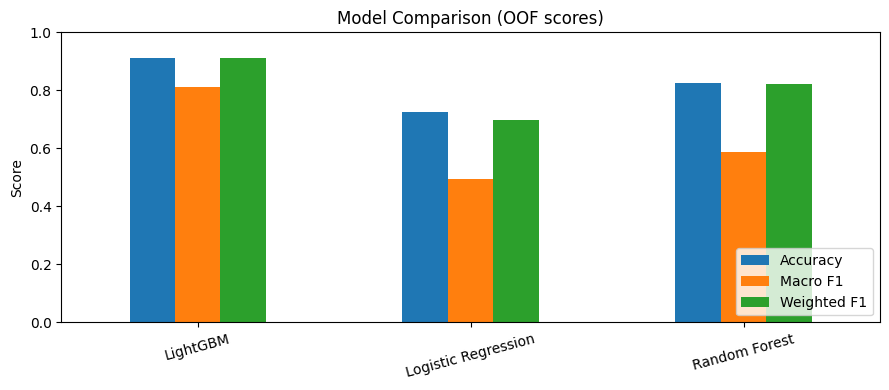

In [15]:
# compare all 3 models using out-of-fold predictions
# OOF gives an unbiased estimate of generalisation performance
results = {}

for name, oof in [('LightGBM', oof_lgb),
                   ('Logistic Regression', oof_lr),
                   ('Random Forest', oof_rf)]:
    preds = oof.argmax(axis=1)
    results[name] = {
        'Accuracy'   : round(accuracy_score(y, preds), 4),
        'Macro F1'   : round(f1_score(y, preds, average='macro'), 4),
        'Weighted F1': round(f1_score(y, preds, average='weighted'), 4),
    }

results_df = pd.DataFrame(results).T
print('OOF Model Comparison:')
display(results_df)

results_df.plot(kind='bar', figsize=(9, 4))
plt.title('Model Comparison (OOF scores)')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


=== LightGBM ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.96    114173
           1       0.77      0.81      0.79     15918
           2       0.85      0.91      0.88     62440
           3       0.70      0.56      0.62      5469

    accuracy                           0.91    198000
   macro avg       0.82      0.81      0.81    198000
weighted avg       0.91      0.91      0.91    198000



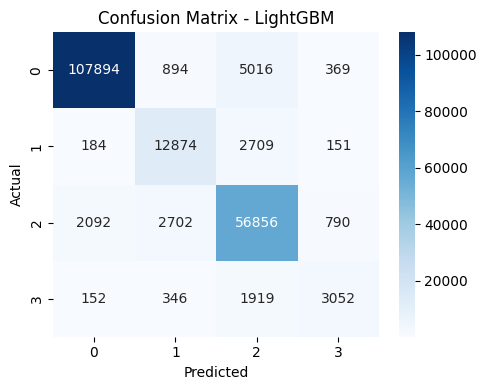


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.74      0.93      0.82    114173
           1       0.54      0.64      0.59     15918
           2       0.76      0.44      0.56     62440
           3       0.12      0.00      0.01      5469

    accuracy                           0.72    198000
   macro avg       0.54      0.50      0.49    198000
weighted avg       0.71      0.72      0.70    198000



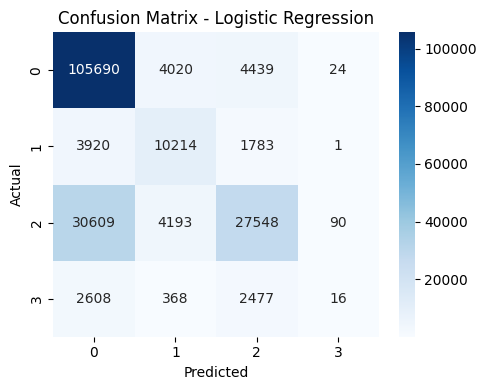


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.96      0.85      0.90    114173
           1       0.49      0.74      0.59     15918
           2       0.74      0.87      0.80     62440
           3       0.64      0.03      0.05      5469

    accuracy                           0.82    198000
   macro avg       0.71      0.62      0.59    198000
weighted avg       0.85      0.82      0.82    198000



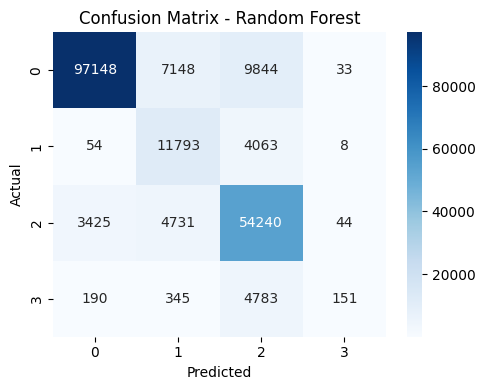

In [16]:
# detailed classification report for each model
for name, oof in [('LightGBM', oof_lgb), ('Logistic Regression', oof_lr), ('Random Forest', oof_rf)]:
    print(f'\n=== {name} ===')
    preds = oof.argmax(axis=1)
    print(classification_report(y, preds))

    cm = confusion_matrix(y, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

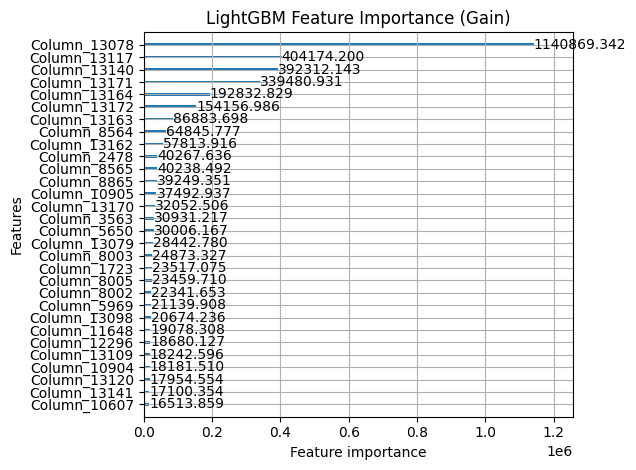

In [17]:
# feature importance from LightGBM (last fold)
lgb.plot_importance(clf, max_num_features=30, importance_type='gain')
plt.title('LightGBM Feature Importance (Gain)')
plt.tight_layout()
plt.show()

### Model insights

- **LightGBM** is by far the best model — it handles the imbalanced classes well with class weights and benefits most from the rich feature set.
- **Logistic Regression** is a strong linear baseline but struggles with class 3 (extremely toxic), which has very few samples.
- **Random Forest** performs between the two but is slower to train and slightly worse than LightGBM.
- The most important features are the **post-level label rate features** (what fraction of a post's comments are each class) — this makes sense because toxicity tends to cluster within threads.
- **Demographic presence** (`demo_count`, target-encoded demographic columns) is a strong signal — label 1 comments have ~2.5 demographic fields filled vs ~0.6 for non-toxic.
- **LightGBM is the best model** and will be used for the final submission.

## 7. Blend + Threshold Tuning (Best Model)

In [18]:
# find the best blend weights for lgbm + logreg by optimising OOF macro-F1
# Nelder-Mead works well here since the objective isn't differentiable

def weight_loss(weights):
    w = np.abs(weights) / np.sum(np.abs(weights))  # normalise to sum to 1
    proba = w[0] * oof_lgb + w[1] * oof_lr
    preds = proba.argmax(axis=1)
    return -f1_score(y, preds, average='macro')

res = minimize(weight_loss, [0.5, 0.1], method='Nelder-Mead', options={'maxiter': 500})
best_w = np.abs(res.x) / np.sum(np.abs(res.x))
lgb_w, lr_w = best_w[0], best_w[1]
print(f'optimized weights -> lgbm: {lgb_w:.3f}, logreg: {lr_w:.3f}')

oof_proba  = lgb_w * oof_lgb + lr_w * oof_lr
blend_pred = oof_proba.argmax(axis=1)
print('blended OOF accuracy:', round(accuracy_score(y, blend_pred), 4))
print('blended OOF macro f1:', round(f1_score(y, blend_pred, average='macro'), 4))

optimized weights -> lgbm: 1.000, logreg: 0.000
blended OOF accuracy: 0.9125
blended OOF macro f1: 0.8127


In [19]:
# tune per-class decision thresholds to improve macro-F1
# dividing by a threshold before argmax shifts the boundary for that class
# this helps with minority classes like class 3 (extremely toxic)

def predict_with_thresholds(proba, thresholds):
    adjusted = proba / thresholds.reshape(1, -1)
    return adjusted.argmax(axis=1)

def f1_loss(thresholds, proba, y_true):
    preds = predict_with_thresholds(proba, thresholds)
    return -f1_score(y_true, preds, average='macro')

res2 = minimize(f1_loss, [1.0, 1.0, 1.0, 1.0],
                args=(oof_proba, y), method='Nelder-Mead',
                options={'maxiter': 500})
best_thresholds = res2.x

y_pred_tuned = predict_with_thresholds(oof_proba, best_thresholds)
print('tuned thresholds:', best_thresholds.round(3).tolist())
print('tuned macro f1  :', round(f1_score(y, y_pred_tuned, average='macro'), 5))
print()
print(classification_report(y, y_pred_tuned))

tuned thresholds: [1.034, 1.014, 1.116, 0.763]
tuned macro f1  : 0.81653

              precision    recall  f1-score   support

           0       0.98      0.95      0.96    114173
           1       0.76      0.81      0.79     15918
           2       0.86      0.90      0.88     62440
           3       0.66      0.61      0.64      5469

    accuracy                           0.91    198000
   macro avg       0.82      0.82      0.82    198000
weighted avg       0.91      0.91      0.91    198000



## 8. Generate Submission

In [20]:
# apply the blended + threshold-tuned model to the test set
test_proba = lgb_w * test_lgb + lr_w * test_lr
test_preds = predict_with_thresholds(test_proba, best_thresholds)

submission = pd.DataFrame({
    'ID'   : test_df['ID'] if 'ID' in test_df.columns else range(1, len(test_preds) + 1),
    'label': test_preds
})

submission.to_csv('/kaggle/working/submission.csv', index=False)
print('saved submission.csv')
print('shape:', submission.shape)
print(submission['label'].value_counts().sort_index())
submission.head()

saved submission.csv
shape: (102000, 2)
label
0    56883
1     8675
2    33882
3     2560
Name: count, dtype: int64


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2
